**ARIMA**

Source:
https://machinelearningmastery.com/arima-for-time-series-forecasting-with-python/

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_4623/663694614.py:9: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series_df = read_excel('/content/drive/MyDrive/DATAHACTHON/forecasting/forecasting_rainfall_dataset.xlsx', header=0, parse_dates=[0], index_col=0, date_parser=parser)


            Suhu Minimum (°C)  Suhu Maksimum (°C)  Suhu Rata-rata (°C)  \
Tanggal                                                                  
2008-02-01               24.0                30.1                 26.1   
2008-02-02               24.0                31.0                 26.3   
2008-02-03               22.6                30.8                 26.0   
2008-02-04               22.8                33.4                 26.9   
2008-02-05               23.0                32.4                 26.9   

            Kelembaban Rata-rata (%)  Lama Penyinaran (jam)  \
Tanggal                                                       
2008-02-01                        82                    2.3   
2008-02-02                        90                    1.0   
2008-02-03                        86                    0.3   
2008-02-04                        84                    0.9   
2008-02-05                        86                    5.0   

            Kecepatan Angin Rata-rata (

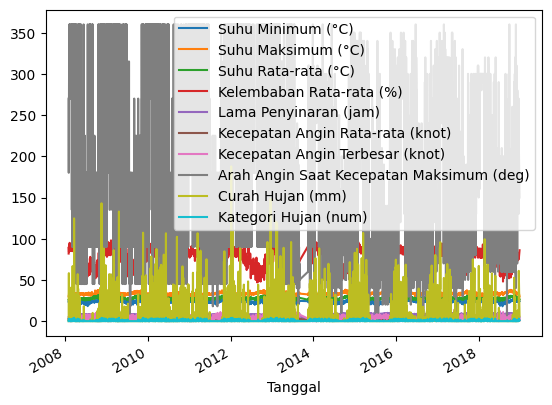

In [3]:
from pandas import read_excel
import datetime  # Import datetime directly
from matplotlib import pyplot

def parser(x):
	return datetime.datetime.strptime(x, '%d/%m/%Y') # Use datetime.datetime

# Read the CSV without 'squeeze'
series_df = read_excel('/content/drive/MyDrive/DATAHACTHON/forecasting/forecasting_rainfall_dataset.xlsx', header=0, parse_dates=[0], index_col=0, date_parser=parser)

# Squeeze the DataFrame into a Series if it has only one column
if len(series_df.columns) == 1:
    series = series_df.squeeze()
else:
    series = series_df  # Keep it as a DataFrame if it has multiple columns

print(series.head())
series.plot()
pyplot.show()

/tmp/ipykernel_4623/486411747.py:10: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series_df = read_excel('/content/drive/MyDrive/DATAHACTHON/forecasting/forecasting_rainfall_dataset.xlsx', header=0, parse_dates=[0], index_col=0, date_parser=parser)
/tmp/ipykernel_4623/486411747.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  series_df[col].fillna(series_df[col].mean(),

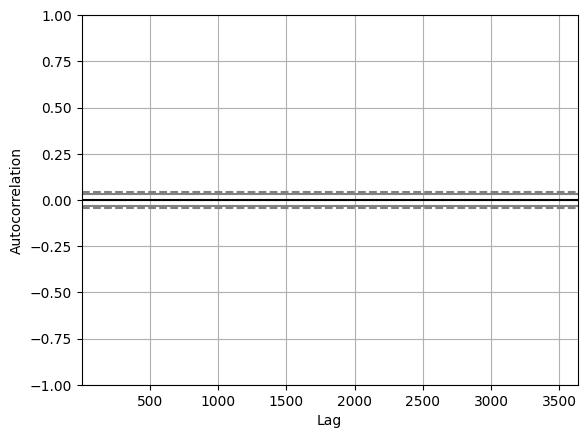

In [4]:
import pandas as pd
import datetime
from matplotlib import pyplot as plt
from pandas.plotting import autocorrelation_plot

def parser(x):
    return datetime.datetime.strptime(x, '%d/%m/%Y')

# Baca file Excel
series_df = read_excel('/content/drive/MyDrive/DATAHACTHON/forecasting/forecasting_rainfall_dataset.xlsx', header=0, parse_dates=[0], index_col=0, date_parser=parser)

# Normalisasi tipe data dalam setiap kolom
for col in series_df.columns:
    if series_df[col].dtype == 'object':  # Jika tipe data kolom adalah string
        # Coba konversi ke numerik, jika gagal, set sebagai NaN
        series_df[col] = pd.to_numeric(series_df[col], errors='coerce')

    # Jika ada NaN yang muncul setelah konversi, misalnya akibat data yang tidak valid
    if series_df[col].isnull().any():
        # Misalnya, ganti NaN dengan nilai rata-rata kolom
        series_df[col].fillna(series_df[col].mean(), inplace=True)

# Jika hanya ada satu kolom, squeeze menjadi Series
if len(series_df.columns) == 1:
    series = series_df.squeeze()
else:
    series = series_df

# Plot autocorrelation
autocorrelation_plot(series)
plt.show()


/tmp/ipykernel_4623/3563008331.py:10: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series_df = pd.read_excel('/content/drive/MyDrive/DATAHACTHON/forecasting/forecasting_rainfall_dataset.xlsx', header=0, parse_dates=[0], index_col=0, date_parser=parser)


                               SARIMAX Results                                
Dep. Variable:      Suhu Minimum (°C)   No. Observations:                 3634
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -4468.824
Date:                Thu, 04 Jun 2026   AIC                           8949.648
Time:                        15:25:37   BIC                           8986.835
Sample:                    02-29-2008   HQIC                          8962.894
                         - 12-31-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5189      0.011    -49.099      0.000      -0.540      -0.498
ar.L2         -0.3954      0.014    -28.638      0.000      -0.422      -0.368
ar.L3         -0.3112      0.014    -21.574      0.0

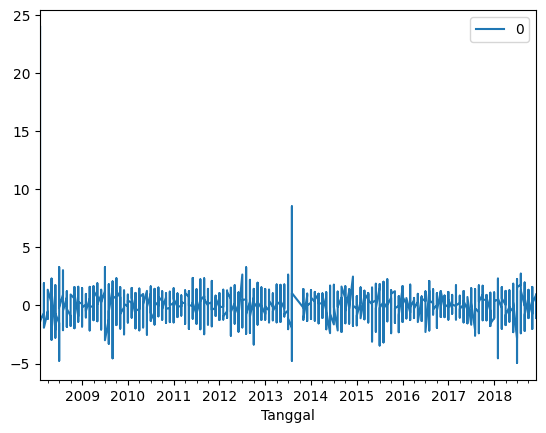

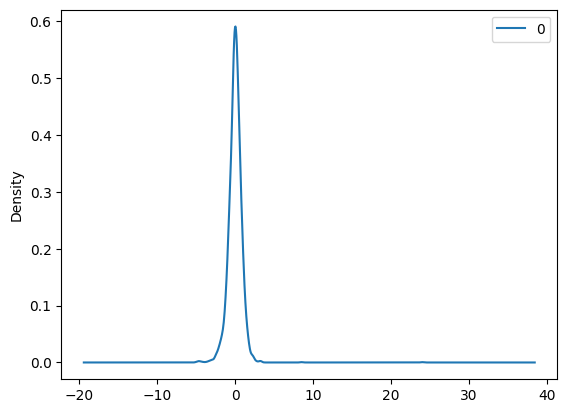

                 0
count  3634.000000
mean      0.006797
std       0.918626
min      -4.947379
25%      -0.444595
50%       0.027862
75%       0.478761
max      24.000000
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3634
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -13396.469
Date:                Thu, 04 Jun 2026   AIC                          26804.939
Time:                        15:25:38   BIC                          26842.126
Sample:                    02-29-2008   HQIC                         26818.185
                         - 12-31-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7331      0.015    -50

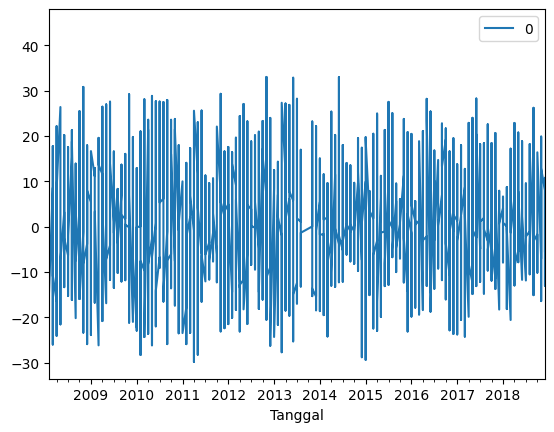

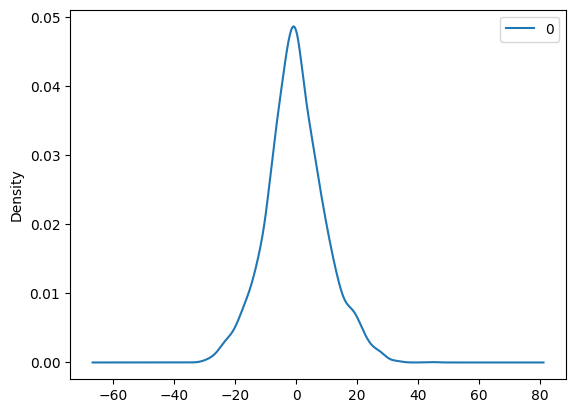

                 0
count  3634.000000
mean      0.007594
std       9.692300
min     -29.795896
25%      -6.019053
50%      -0.328893
75%       5.699397
max      44.250000


In [5]:
import pandas as pd
import datetime
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot as plt

def parser(x):
    return datetime.datetime.strptime(x, '%d/%m/%Y')

# Baca file Excel
series_df = pd.read_excel('/content/drive/MyDrive/DATAHACTHON/forecasting/forecasting_rainfall_dataset.xlsx', header=0, parse_dates=[0], index_col=0, date_parser=parser)

# Squeeze the DataFrame into a Series if it has only one column
if len(series_df.columns) == 1:
    series = series_df.squeeze()
else:
    series = series_df  # Keep it as a DataFrame if it has multiple columns

# Konversi index menjadi periodik bulanan
series.index = series.index.to_period('M')

# Explicitly convert all columns to numeric, forcing non-convertible values to NaN
for col in series.columns:
    series[col] = pd.to_numeric(series[col], errors='coerce')

# Fill NaN values (if any) with a suitable strategy, e.g., mean
series.fillna(series.mean(), inplace=True)

# === SOLUSI 1: Pilih satu kolom untuk dianalisis ===
column_to_analyze = series.iloc[:, 0]  # Memilih kolom pertama

# fit model untuk kolom yang dipilih
model = ARIMA(column_to_analyze, order=(5,1,0))
model_fit = model.fit()

# summary of fit model
print(model_fit.summary())

# line plot of residuals
residuals = pd.DataFrame(model_fit.resid)
residuals.plot()
plt.show()

# density plot of residuals
residuals.plot(kind='kde')
plt.show()

# summary stats of residuals
print(residuals.describe())

# === SOLUSI 2: Agregasi kolom ===
aggregated_series = series.mean(axis=1)  # Rata-rata semua kolom

# fit model untuk data yang di agregasi
model = ARIMA(aggregated_series, order=(5,1,0))
model_fit = model.fit()

# summary of fit model
print(model_fit.summary())

# line plot of residuals
residuals = pd.DataFrame(model_fit.resid)
residuals.plot()
plt.show()

# density plot of residuals
residuals.plot(kind='kde')
plt.show()

# summary stats of residuals
print(residuals.describe())


/tmp/ipykernel_4623/3226312240.py:12: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series_df = pd.read_excel('/content/drive/MyDrive/DATAHACTHON/forecasting/forecasting_rainfall_dataset.xlsx', header=0, parse_dates=[0], index_col=0, date_parser=parser)


predicted=24.514639, expected=23.600000
predicted=24.153481, expected=24.000000
predicted=24.207943, expected=24.000000
predicted=24.243149, expected=24.200000
predicted=24.110938, expected=24.000000
predicted=24.129106, expected=23.800000
predicted=23.865370, expected=24.000000
predicted=23.995166, expected=23.600000
predicted=23.823503, expected=24.400000
predicted=24.126517, expected=23.000000
predicted=23.576088, expected=23.000000
predicted=23.379791, expected=24.000000
predicted=23.797007, expected=23.800000
predicted=23.678788, expected=23.400000
predicted=23.591550, expected=24.000000
predicted=23.671491, expected=23.800000
predicted=23.680463, expected=24.200000
predicted=23.975719, expected=24.000000
predicted=23.938723, expected=24.000000
predicted=23.897329, expected=22.200000
predicted=23.228393, expected=22.400000
predicted=23.034465, expected=23.800000
predicted=23.575091, expected=24.000000
predicted=23.632395, expected=24.200000
predicted=23.762481, expected=24.200000


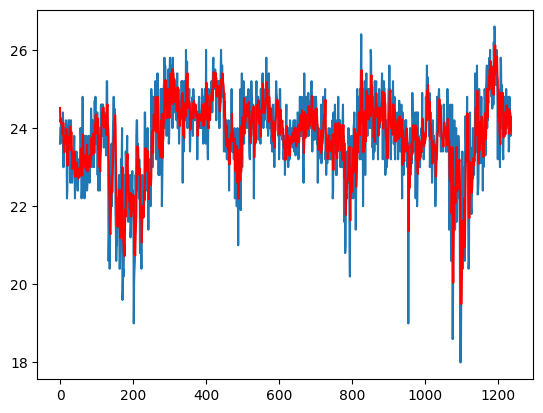

In [6]:
import pandas as pd
import datetime
from matplotlib import pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt

def parser(x):
    return datetime.datetime.strptime(x, '%d/%m/%Y')

# Baca file Excel
series_df = pd.read_excel('/content/drive/MyDrive/DATAHACTHON/forecasting/forecasting_rainfall_dataset.xlsx', header=0, parse_dates=[0], index_col=0, date_parser=parser)

# Squeeze the DataFrame into a Series jika hanya ada satu kolom
if len(series_df.columns) == 1:
    series = series_df.squeeze()
else:
    series = series_df  # Tetap dalam bentuk DataFrame jika memiliki beberapa kolom

series.index = series.index.to_period('M')

# Explicitly convert all columns to numeric, forcing non-convertible values to NaN
for col in series.columns:
    series[col] = pd.to_numeric(series[col], errors='coerce')

# Fill NaN values (if any) with a suitable strategy, e.g., mean
series.fillna(series.mean(), inplace=True)

# === SOLUSI 1: Pilih satu kolom untuk dianalisis ===
column_to_analyze = series.iloc[:, 0]  # Memilih kolom pertama

# === SOLUSI 2: Agregasi kolom ===
# aggregated_series = series.mean(axis=1)  # Rata-rata semua kolom
# Untuk Solusi 2, gunakan aggregated_series di tempat column_to_analyze pada kode berikut ini

# Gunakan data dari Solusi 1 atau Solusi 2
X = column_to_analyze.values  # atau aggregated_series.values jika menggunakan agregasi

# split into train and test sets
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = list()

# walk-forward validation
for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = test[t]
    history.append(obs)
    print('predicted=%f, expected=%f' % (yhat, obs))

# evaluate forecasts
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)

# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()


**TUNING PARAMETERS BY ARIMA**

SOURCE:
https://machinelearningmastery.com/grid-search-arima-hyperparameters-with-python/

In [7]:
import warnings
import pandas as pd
import datetime
from math import sqrt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# evaluate an ARIMA model for a given order (p,d,q)
def evaluate_arima_model(X, arima_order):
    # prepare training dataset
    train_size = int(len(X) * 0.66)
    train, test = X[0:train_size], X[train_size:]
    history = [x for x in train]
    # make predictions
    predictions = list()
    for t in range(len(test)):
        model = ARIMA(history, order=arima_order)
        model_fit = model.fit()
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)
        history.append(test[t])
    # calculate out of sample error
    rmse = sqrt(mean_squared_error(test, predictions))
    return rmse

# evaluate combinations of p, d and q values for an ARIMA model
def evaluate_models(dataset, p_values, d_values, q_values):
    dataset = dataset.astype('float32')
    best_score, best_cfg = float("inf"), None
    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p,d,q)
                try:
                    rmse = evaluate_arima_model(dataset, order)
                    if rmse < best_score:
                        best_score, best_cfg = rmse, order
                    print('ARIMA%s RMSE=%.3f' % (order,rmse))
                except:
                    continue
    print('Best ARIMA%s RMSE=%.3f' % (best_cfg, best_score))

# Preprocessing function
def preprocess_data(df):
    # Convert all columns to numeric, forcing non-convertible values to NaN
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    # Fill NaN values with the mean of the column
    df.fillna(df.mean(), inplace=True)
    return df

# load dataset
def parser(x):
    return datetime.datetime.strptime(x, '%d/%m/%Y')

# Read the CSV without 'squeeze'
series_df = pd.read_excel('/content/drive/MyDrive/DATAHACTHON/forecasting/forecasting_rainfall_dataset.xlsx', header=0, parse_dates=[0], index_col=0, date_parser=parser)

# Preprocess the dataset
series_df = preprocess_data(series_df)

# Squeeze the DataFrame into a Series if it has only one column
if len(series_df.columns) == 1:
    series = series_df.squeeze()
else:
    series = series_df  # Keep it as a DataFrame if it has multiple columns

# Evaluate parameters
p_values = [0, 1, 2, 4, 6, 8, 10]
d_values = range(0, 3)
q_values = range(0, 3)
warnings.filterwarnings("ignore")
evaluate_models(series.values, p_values, d_values, q_values)


Best ARIMANone RMSE=inf


/tmp/ipykernel_4623/245353801.py:57: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series_df = pd.read_excel('/content/drive/MyDrive/DATAHACTHON/forecasting/forecasting_rainfall_dataset.xlsx', header=0, parse_dates=[0], index_col=0, date_parser=parser)


In [10]:
import os
import joblib

# Folder output di Drive
output_dir = '/content/drive/MyDrive/DATAHACTHON/forecasting'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Menyimpan seluruh objek model
model_save_path = os.path.join(output_dir, 'arima_full_model.pkl')
joblib.dump(model_fit, model_save_path)

print(f'Model berhasil disimpan secara utuh di: {model_save_path}')

Model berhasil disimpan secara utuh di: /content/drive/MyDrive/DATAHACTHON/forecasting/arima_full_model.pkl


### Cara Menggunakan Model yang Sudah Disimpan

Setelah Anda menyimpan hasil dan memiliki objek `model_fit`, Anda dapat melakukan langkah-langkah berikut:
1. **Membaca Ringkasan**: Melihat kembali performa statistik model.
2. **Forecasting**: Memprediksi nilai untuk beberapa hari/bulan ke depan.
3. **Deployment**: Menggunakan model ini dalam aplikasi lain.

In [11]:
import joblib
import os

# --- CONTOH PEMANGGILAN MODEL DI PROJEK LAIN ---
def use_saved_model(path, steps=5):
    if os.path.exists(path):
        # 1. Load model
        loaded_model = joblib.load(path)
        print("Model Berhasil Dimuat.\n")

        # 2. Melakukan peramalan (Forecast)
        forecast = loaded_model.forecast(steps=steps)
        print(f"Hasil Peramalan untuk {steps} periode ke depan:")
        print(forecast)
        return forecast
    else:
        print("Error: File model tidak ditemukan!")

# Menjalankan fungsi contoh
model_path = '/content/drive/MyDrive/DATAHACTHON/forecasting/arima_full_model.pkl'
peramalan_baru = use_saved_model(model_path, steps=5)

Model Berhasil Dimuat.

Hasil Peramalan untuk 5 periode ke depan:
[23.93631468 23.97759202 24.13392549 24.08913853 24.09581111]


### Peramalan Berdasarkan Tanggal Hari Ini

Karena dataset berakhir pada **2018-12-31**, kita perlu menghitung berapa banyak periode (bulan) yang telah berlalu hingga hari ini agar bisa memulai prediksi dari bulan ini.

In [16]:
from datetime import datetime
import pandas as pd
import joblib
import numpy as np

# 1. Ambil tanggal terakhir dari data asli
last_val = series.index[-1]
if hasattr(last_val, 'to_timestamp'):
    last_data_date = last_val.to_timestamp()
else:
    last_data_date = pd.to_datetime(last_val)

# 2. Ambil tanggal hari ini
today = datetime.now()

# 3. Hitung selisih bulan antara data terakhir dan hari ini
diff_in_months = (today.year - last_data_date.year) * 12 + (today.month - last_data_date.month)

# 4. Lakukan forecast
steps_ahead = 12
total_steps = max(1, diff_in_months + steps_ahead)

model_path = '/content/drive/MyDrive/DATAHACTHON/forecasting/arima_full_model.pkl'
loaded_model = joblib.load(model_path)

all_forecast = loaded_model.forecast(steps=total_steps)

# 5. Ambil bagian yang dimulai dari bulan ini
# all_forecast adalah numpy array, jadi kita gunakan slicing langsung
if diff_in_months > 0:
    forecast_from_today = all_forecast[diff_in_months-1:]
else:
    forecast_from_today = all_forecast

# 6. Beri label tanggal (Mulai dari bulan ini)
forecast_index = pd.date_range(start=today.replace(day=1), periods=len(forecast_from_today), freq='MS')
# Perbaikan: hilangkan .values karena forecast_from_today sudah berupa numpy array
forecast_final = pd.Series(forecast_from_today, index=forecast_index)

print(f"Tanggal Terakhir di Dataset: {last_data_date.strftime('%Y-%m')}")
print(f"Tanggal Sekarang: {today.strftime('%Y-%m')}")
print(f"\nPrediksi {len(forecast_final)} Bulan ke Depan (Mulai Sekarang):")
print(forecast_final)

Tanggal Terakhir di Dataset: 2018-12
Tanggal Sekarang: 2026-06

Prediksi 13 Bulan ke Depan (Mulai Sekarang):
2026-06-01 15:45:07.909977    24.056752
2026-07-01 15:45:07.909977    24.056752
2026-08-01 15:45:07.909977    24.056752
2026-09-01 15:45:07.909977    24.056752
2026-10-01 15:45:07.909977    24.056752
2026-11-01 15:45:07.909977    24.056752
2026-12-01 15:45:07.909977    24.056752
2027-01-01 15:45:07.909977    24.056752
2027-02-01 15:45:07.909977    24.056752
2027-03-01 15:45:07.909977    24.056752
2027-04-01 15:45:07.909977    24.056752
2027-05-01 15:45:07.909977    24.056752
2027-06-01 15:45:07.909977    24.056752
Freq: MS, dtype: float64


In [18]:
import joblib
import os
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# Memastikan folder output ada
output_dir = '/content/drive/MyDrive/DATAHACTHON/forecasting'

# List kolom yang akan diprediksi
target_columns = ['Suhu Maksimum (°C)', 'Suhu Rata-rata (°C)']
forecasts_results = {}

# Gunakan tanggal yang 'bersih' (awal bulan saja) untuk index
clean_start_date = today.replace(day=1, hour=0, minute=0, second=0, microsecond=0)

for col_name in target_columns:
    print(f"Melatih model untuk: {col_name}...")

    # Ambil data kolom terkait
    column_data = series[col_name]

    # Latih model
    model = ARIMA(column_data, order=(5,1,0))
    model_fit = model.fit()

    # Simpan model
    safe_name = col_name.replace(' (°C)', '').replace(' ', '_').lower()
    model_path = os.path.join(output_dir, f'arima_{safe_name}_model.pkl')
    joblib.dump(model_fit, model_path)

    # Lakukan forecast
    all_forecast = model_fit.forecast(steps=total_steps)

    # Ambil bagian dari bulan ini
    if diff_in_months > 0:
        forecast_today = all_forecast[diff_in_months-1:]
    else:
        forecast_today = all_forecast

    forecasts_results[col_name] = forecast_today

print("\n--- HASIL PREDIKSI MULAI BULAN INI ---")
for col_name, values in forecasts_results.items():
    # Buat index baru yang bersih
    new_forecast_index = pd.date_range(start=clean_start_date, periods=len(values), freq='MS')
    # Pastikan data dikonversi ke list/array agar tidak ada masalah alignment index lama
    final_s = pd.Series(values.values if hasattr(values, 'values') else values, index=new_forecast_index)
    print(f"\nPrediksi {col_name}:")
    print(final_s.head(12))

Melatih model untuk: Suhu Maksimum (°C)...
Melatih model untuk: Suhu Rata-rata (°C)...

--- HASIL PREDIKSI MULAI BULAN INI ---

Prediksi Suhu Maksimum (°C):
2026-06-01    32.731637
2026-07-01    32.731637
2026-08-01    32.731637
2026-09-01    32.731637
2026-10-01    32.731637
2026-11-01    32.731637
2026-12-01    32.731637
2027-01-01    32.731637
2027-02-01    32.731637
2027-03-01    32.731637
2027-04-01    32.731637
2027-05-01    32.731637
Freq: MS, dtype: float64

Prediksi Suhu Rata-rata (°C):
2026-06-01    27.465749
2026-07-01    27.465749
2026-08-01    27.465749
2026-09-01    27.465749
2026-10-01    27.465749
2026-11-01    27.465749
2026-12-01    27.465749
2027-01-01    27.465749
2027-02-01    27.465749
2027-03-01    27.465749
2027-04-01    27.465749
2027-05-01    27.465749
Freq: MS, dtype: float64
